In [ ]:
# Step 1: Import Required Libraries

In [14]:
import pandas as pd # loading data
import numpy as np # mathematical calculations
import re # regular expressions for cleaning the data
import nltk # for basic
import matplotlib.pyplot as plt # visualization
from nltk.corpus import stopwords # to remove be verbs unwanted words
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer # for sentiment analysis
from collections import Counter
from wordcloud import WordCloud



# Download required NLTK files
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')
nltk.download('punkt_tab')




[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
# Step 2: Create Sample Customer Reviews

In [15]:
data = {
    "Review": [
        "The product quality is excellent and delivery was very fast.",
        "Very bad packaging and the item was damaged.",
        "Customer service was helpful and responsive.",
        "The delivery was delayed and support team did not respond.",
        "Amazing product. Worth the money.",
        "Poor quality product and terrible experience.",
        "Fast shipping and good packaging.",
        "The product stopped working after two days.",
        "Excellent service and great quality.",
        "Late delivery and bad customer support."
    ]
}

# Create DataFrame
df = pd.DataFrame(data)

# Display first few rows
print("Customer Reviews Dataset:")
print(df.head())



Customer Reviews Dataset:
                                              Review
0  The product quality is excellent and delivery ...
1       Very bad packaging and the item was damaged.
2       Customer service was helpful and responsive.
3  The delivery was delayed and support team did ...
4                  Amazing product. Worth the money.


In [ ]:
# Step 3: Data Cleaning and  Preprocessing

In [21]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

       # convert to lowercase
       text = text.lower()
       print('lower case', text)

       # remove special characters and numbers
       text=re.sub(r'[^a-zA-Z\s]', '', text)
       print('special character', text)

       #Tokenization
       words= word_tokenize(text)
       print('tokenization', words)

       # Remove stopwords
       words = [word for word in words if word not in stop_words]
       print('stopwords', words)

       # Join words again
       cleaned_text = ' '.join(words)
       return cleaned_text

# Apply cleaning function
df['Cleaned_Review'] = df['Review'].apply(clean_text)

# Display cleaned reviews
print("\nCleaned Reviews:")
print(df[['Review', 'Cleaned_Review']])




lower case the product quality is excellent and delivery was very fast.
special character the product quality is excellent and delivery was very fast
tokenization ['the', 'product', 'quality', 'is', 'excellent', 'and', 'delivery', 'was', 'very', 'fast']
stopwords ['product', 'quality', 'excellent', 'delivery', 'fast']
lower case very bad packaging and the item was damaged.
special character very bad packaging and the item was damaged
tokenization ['very', 'bad', 'packaging', 'and', 'the', 'item', 'was', 'damaged']
stopwords ['bad', 'packaging', 'item', 'damaged']
lower case customer service was helpful and responsive.
special character customer service was helpful and responsive
tokenization ['customer', 'service', 'was', 'helpful', 'and', 'responsive']
stopwords ['customer', 'service', 'helpful', 'responsive']
lower case the delivery was delayed and support team did not respond.
special character the delivery was delayed and support team did not respond
tokenization ['the', 'delivery'

In [23]:
# Step 4: Sentiment Analysis

In [22]:
sia=SentimentIntensityAnalyzer()

def analyze_sentiment(review):
    score = sia.polarity_scores(review)

    compound = score['compound']

    if compound >= 0.05:
        return 'Positive'
    elif compound <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Apply sentiment Analysis
df['sentiment'] = df['Cleaned_Review'].apply(analyze_sentiment)

# Display sentiment analysis results
print("\nSentiment Analysis Results:")
print(df[['Review', 'sentiment']])


Sentiment Analysis Results:
                                              Review sentiment
0  The product quality is excellent and delivery ...  Positive
1       Very bad packaging and the item was damaged.  Negative
2       Customer service was helpful and responsive.  Positive
3  The delivery was delayed and support team did ...  Positive
4                  Amazing product. Worth the money.  Positive
5      Poor quality product and terrible experience.  Negative
6                  Fast shipping and good packaging.  Positive
7        The product stopped working after two days.  Negative
8               Excellent service and great quality.  Positive
9            Late delivery and bad customer support.  Negative


In [ ]:
# step 5: Find Common Keywords

In [24]:
all_words =" ".join(df['Cleaned_Review'])
word_list = all_words.split()

# Count word frequency
word_freq= Counter(word_list)

# Display top 10 keywords
print("\nTop 10 Keywords:")
print(word_freq.most_common(10))



Top 10 Keywords:
[('product', 4), ('quality', 3), ('delivery', 3), ('excellent', 2), ('fast', 2), ('bad', 2), ('packaging', 2), ('customer', 2), ('service', 2), ('support', 2)]


In [ ]:
# Step 6: Identify Common Complaints

In [25]:
negative_reviews = df[df['sentiment'] == 'Negative']
negative_words = " ".join(negative_reviews['Cleaned_Review'])
negative_word_list = negative_words.split()
complaint_freq = Counter(negative_word_list)

# Display top 10 common complaints
print("\nTop 10 Common Complaints:")
print(complaint_freq.most_common(10))



Top 10 Common Complaints:
[('bad', 2), ('product', 2), ('packaging', 1), ('item', 1), ('damaged', 1), ('poor', 1), ('quality', 1), ('terrible', 1), ('experience', 1), ('stopped', 1)]


In [ ]:
# Step 7:Visualization - Sentiment Count

In [26]:
sentiment_counts = df['sentiment'].value_counts()
sentiment_counts


,count
sentiment,
Positive,6
Negative,4


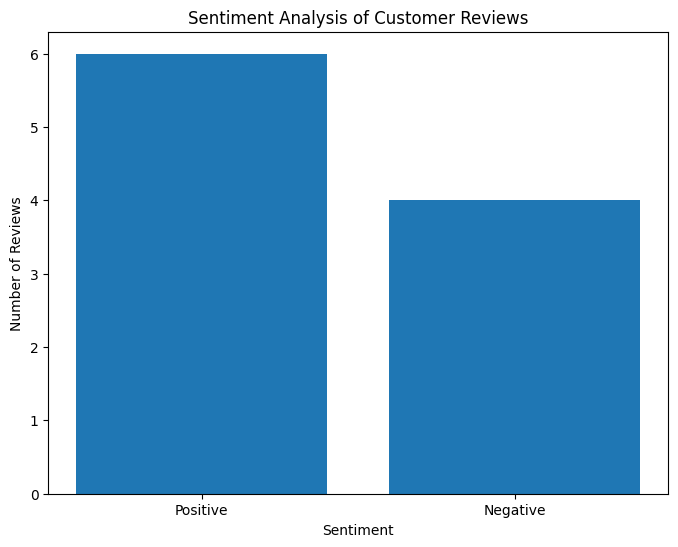

In [27]:
sentiment_counts = df['sentiment'].value_counts() # it will give category count

# Create a bar chart
plt.figure(figsize=(8, 6))
plt.bar(sentiment_counts.index, sentiment_counts.values)
plt.title('Sentiment Analysis of Customer Reviews')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

In [28]:
# Step 8: Generate Word Cloud

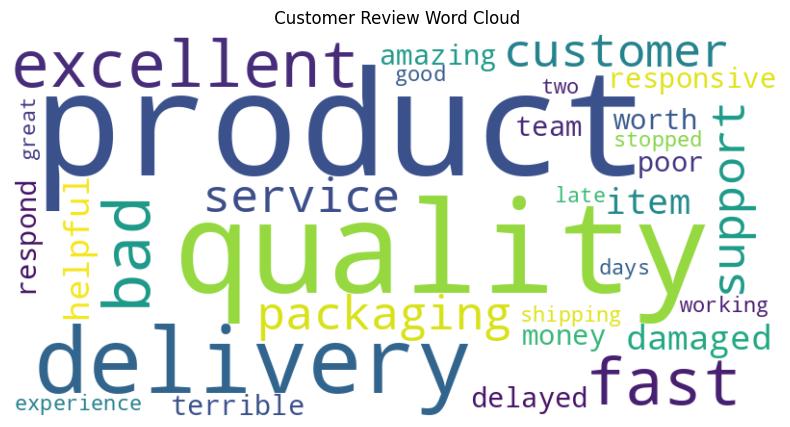

In [29]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
    ).generate(all_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title(' Customer Review Word Cloud')
plt.show()
